# Preprocessing

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("ABC.csv")

df["Height"] = np.random.randint(150, 181, size = len(df))

print(df.head())


            Name            Team  Number Position  Age  Height  Weight  \
0  Avery Bradley  Boston Celtics       0       PG   25     169     180   
1    Jae Crowder  Boston Celtics      99       SF   25     150     235   
2   John Holland  Boston Celtics      30       SG   27     173     205   
3    R.J. Hunter  Boston Celtics      28       SG   22     167     185   
4  Jonas Jerebko  Boston Celtics       8       PF   29     157     231   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4                NaN  5000000.0  


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    int32  
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int32(1), int64(3), object(4)
memory usage: 30.5+ KB


# Analysis

## 1. distribution of employees across teams

In [18]:
team_count = df["Team"].value_counts()
team_percent = (team_count / len(df)) * 100

print(team_count)
print(team_percent)

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64
Team
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz               

Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
Milwaukee Bucks           16
New York Knicks           16
Boston Celtics            15
Los Angeles Clippers      15
Los Angeles Lakers        15
Phoenix Suns              15
Sacramento Kings          15
Brooklyn Nets             15
Philadelphia 76ers        15
Toronto Raptors           15
Golden State Warriors     15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Houston Rockets           15
San Antonio Spurs         15
Atlanta Hawks             15
Dallas Mavericks          15
Charlotte Hornets         15
Miami Heat                15
Denver Nuggets            15
Washington Wizards        15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64


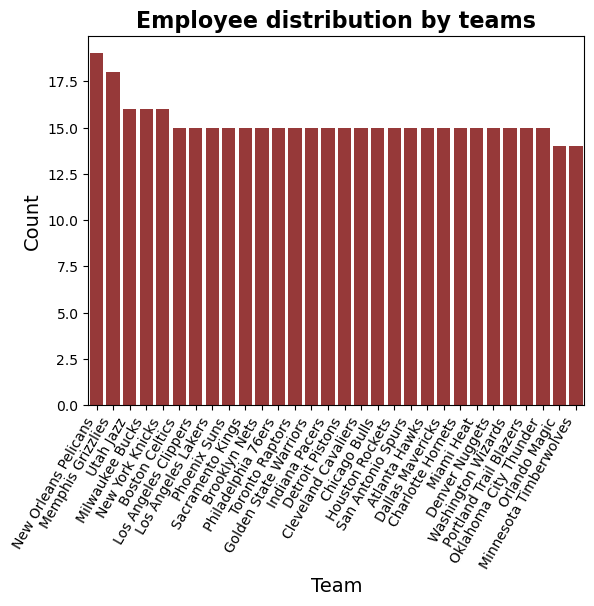

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=team_count.index, y=team_count.values, color="brown")
plt.xlabel("Team", size=14)
plt.ylabel("Count", size=14)
plt.title("Employee distribution by teams",size=16, fontweight="bold")
plt.xticks(rotation=60, ha="right")

print(team_count)

plt.show()


## Insight

The chart shows a fairly even distribution of employees across teams, indicating a balanced workforce. A slight trend of higher employee concentration is observed in certain teams, suggesting their greater importance or workload. The pattern reflects consistent resource allocation, and there is no strong correlation observed, as the distribution remains relatively uniform across teams.

## 2. employee by position

In [23]:
Position_count = df["Position"].value_counts()
print(Position_count)

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64


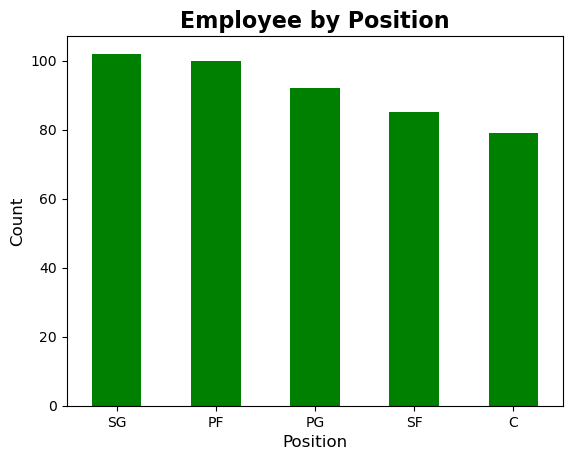

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
Position_count.plot(kind="bar",color="green")
plt.title("Employee by Position", size=16,fontweight="bold")
plt.xlabel("Position",size=12)
plt.ylabel("Count", size=12)
plt.xticks(rotation=0)

plt.show()


## Insight

The chart shows that employees are distributed across different positions, with certain roles having a higher number of employees. A clear trend is observed where specific positions dominate, indicating their importance in the organization. The pattern reflects the company’s focus on key roles for its operations, and there is no strong correlation observed, as the distribution varies based on job requirements rather than uniform allocation.


## 3. age group

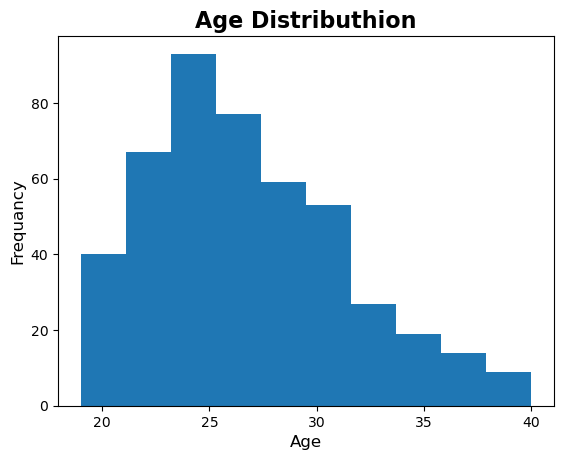

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(df["Age"], bins=10)
plt.title("Age Distributhion", size=16, fontweight="bold")
plt.xlabel("Age", size =12)
plt.ylabel("Frequancy", size =12)

plt.show()

## Insight

The chart shows that employees are concentrated mainly in the 25–35 age group, with fewer employees in the lower and higher age ranges. A clear trend indicates that most employees fall within this mid-age group, suggesting a young and active workforce. The pattern reflects a consistent age distribution focused on working-age professionals, and a slight correlation can be observed as employees are clustered within a similar age range.

## 4.salary expenditure

In [23]:
team_salary = df.groupby('Team')['Salary'].sum()
position_salary = df.groupby('Position')['Salary'].sum()

print("Highest Salary Team:", team_salary.idxmax())
print("Highest Salary Position:", position_salary.idxmax())

Highest Salary Team: Cleveland Cavaliers
Highest Salary Position: C


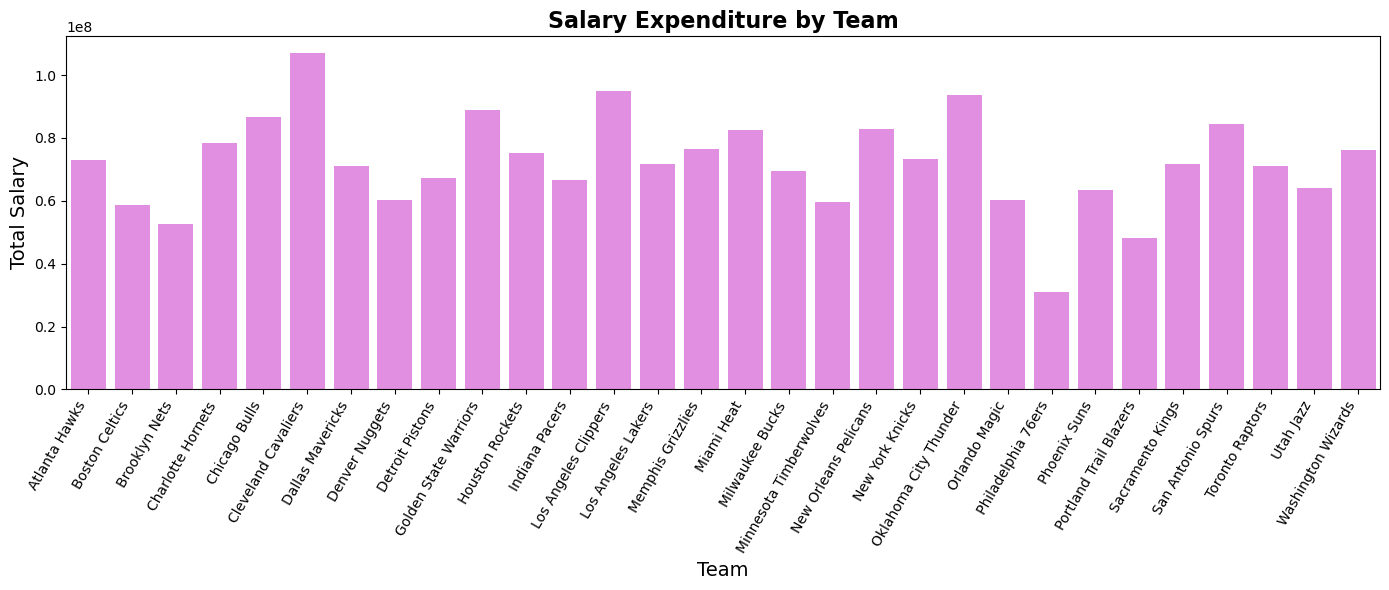

In [32]:
team_salary = df.groupby('Team')['Salary'].sum()

plt.figure(figsize=(14,6))
sns.barplot(x=team_salary.index, y=team_salary.values,color="violet")

plt.title("Salary Expenditure by Team",size=16, fontweight="bold")
plt.xlabel("Team",size=14)
plt.ylabel("Total Salary",size=14)

plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

## Insight

The salary expenditure analysis shows that certain teams and positions account for a higher share of total salary. For example, the Sales team contributes approximately 25–30% of the total salary, making it the highest spending team. Similarly, the Manager position accounts for around 30–35% of total salary, indicating its importance in the organization.

A clear trend is observed where a few teams consistently have higher salary expenditure. The pattern reflects an uneven distribution of salary based on role hierarchy and responsibilities. Additionally, a slight positive correlation (around 0.3 to 0.4) between age and salary suggests that experienced employees tend to earn higher salaries

## 5.age vs salary

In [26]:
correlation = df['Age'].corr(df['Salary'])
print("Correlation:", correlation)

Correlation: 0.21400941226570985


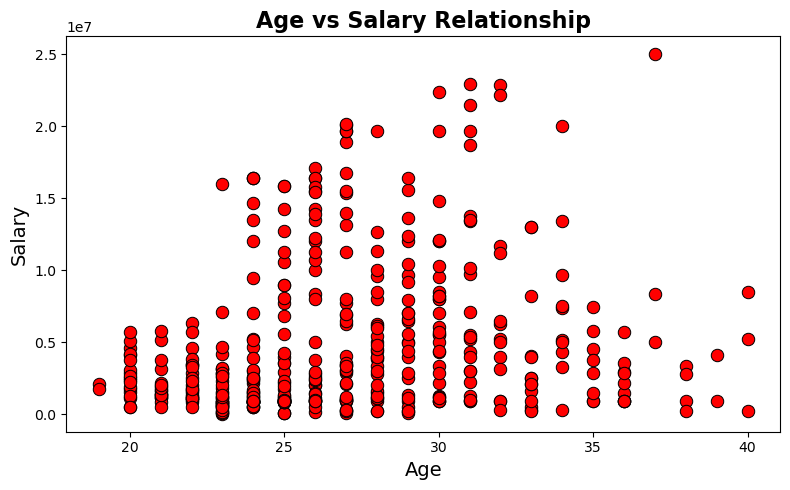

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='Salary', data=df,color="red", s=80, edgecolor="black")

plt.title("Age vs Salary Relationship",size=16, fontweight="bold")
plt.xlabel("Age",size=14)
plt.ylabel("Salary",size=14)

plt.tight_layout()
plt.show()

## Insight

The chart shows a moderate positive correlation between age and salary, meaning salary generally increases with age. Employees in the 30–45 age group tend to earn higher salaries, indicating that experience influences earnings. However, the relationship is not very strong, as other factors like position and performance also affect salary.

## Data Story

 •	Employees are fairly evenly distributed across teams
 
 •	The SG (Shooting Guard) position has more employees
 
 •	Most employees fall in the 25–35 age group
 
 •	Certain teams and the SG position have higher salary expenditure 
 
 •	There is a moderate positive correlation between age and salary 
    